# Arabic visual-description lab

This notebook mirrors the POC's image and video-description step. It loads an image or video, samples videos every 20 seconds, displays each sampled frame, and sends the frame to the configured vision model.

**Important boundary:** descriptions can report visible objects, counts, colours, placement, architectural details and readable text. They must not identify or name a person from a face. To test a name-based retrieval flow, use a source that has a readable lower-third, subtitle, title card, transcript, or trusted publisher metadata naming the person.

## 1. Select media

Set `INPUT_PATH` to any local image or video. The default uses a landmark image already included in the POC. Videos are sampled at the same `fps=1/N:start_time=0:round=up` grid used by the pipeline.

In [25]:
from datetime import datetime
from pathlib import Path
import json
import os
import subprocess
import sys
from dotenv import load_dotenv

ROOT = Path.cwd()
if not (ROOT / 'arabic_poc').exists():
    ROOT = ROOT.parent

# Make the repository package importable when the notebook opens from a subdirectory.
sys.path.insert(0, str(ROOT.resolve()))
load_dotenv(ROOT / '.env', override=True)

# Replace this with your own local image or video.
INPUT_PATH = ROOT / 'data' / 'visual_samples' / 'abs.jpg'
FRAME_SECONDS = 20
assert INPUT_PATH.is_file(), f'File not found: {INPUT_PATH}'
assert FRAME_SECONDS > 0
print(f'Input: {INPUT_PATH}')
print(f"Vision model: {os.getenv('REMOTE_VISION_MODEL', '<unset>')}")


Input: /Users/ushnah.abbasi/RAG-Anything/data/visual_samples/abs.jpg
Vision model: inhouse/gemma-4-12b


## 2. Load one image or sample a video

Frames are saved under `arabic_poc/notebook_frames/` so you can inspect or reuse them after the notebook finishes.

In [26]:
IMAGE_SUFFIXES = {'.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp', '.webp'}
VIDEO_SUFFIXES = {'.mp4', '.mkv', '.mov', '.webm', '.avi'}

def command(*args):
    return subprocess.run(args, check=True, capture_output=True, text=True).stdout

def sample_media(path, interval):
    if path.suffix.lower() in IMAGE_SUFFIXES:
        return [(path, None)]
    if path.suffix.lower() not in VIDEO_SUFFIXES:
        raise ValueError('Choose an image or supported video file.')
    probe = json.loads(command('ffprobe', '-v', 'error', '-show_format', '-of', 'json', str(path)))
    duration = float(probe['format']['duration'])
    folder = ROOT / 'arabic_poc' / 'notebook_frames' / f'{path.stem}-{datetime.now():%Y%m%d-%H%M%S}'
    folder.mkdir(parents=True, exist_ok=False)
    command('ffmpeg', '-v', 'error', '-i', str(path), '-vf',
            f'fps=1/{interval}:start_time=0:round=up,scale=640:-2', str(folder / '%06d.jpg'))
    frames = [(frame, index * interval) for index, frame in enumerate(sorted(folder.glob('*.jpg')))
              if index * interval < duration]
    return frames

frames = sample_media(INPUT_PATH, FRAME_SECONDS)
print(f'{len(frames)} image/frame input(s)')
[(path.name, timestamp) for path, timestamp in frames]


1 image/frame input(s)


[('abs.jpg', None)]

### Image

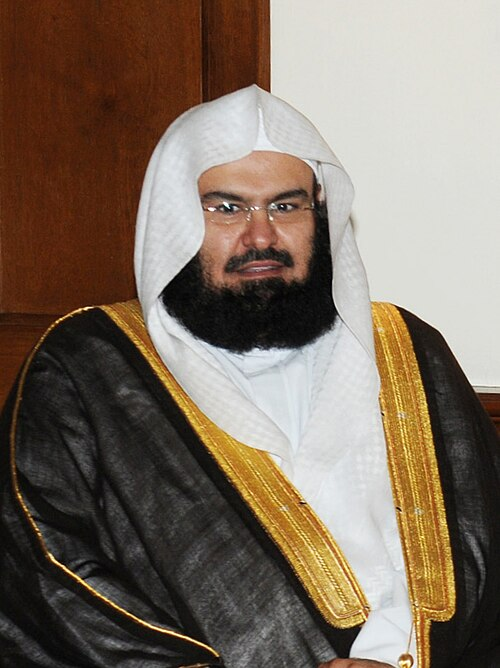

In [27]:
from IPython.display import display, Image as DisplayImage, Markdown

for path, timestamp in frames:
    label = 'Image' if timestamp is None else f'Video frame at {timestamp:.0f}s'
    display(Markdown(f'### {label}'))
    display(DisplayImage(filename=str(path), width=720))


## 3. Describe the frames

The adapter uses the POC configuration in `.env`: remote Gemma when `VISION_BACKEND=remote`, or local Qwen2.5-VL when `VISION_BACKEND=local`. The description request asks for scene, visible objects/count, visible text, placement/colours and architectural details. A count should be reported only when the object is fully visible and unambiguous.

In [ ]:
import importlib
import arabic_poc.models as models
import arabic_poc.remote as remote

importlib.reload(remote)
importlib.reload(models)
from arabic_poc.models import image_parser
from arabic_poc.remote import enabled

VISION_MODEL = 'models/qwen2.5-vl-3b'
vision = image_parser(VISION_MODEL, describe=True)
provider = 'remote vision model' if enabled('vision') else 'local Qwen2.5-VL'
print(f'Description provider: {provider}')


ImportError: cannot import name 'HfFolder' from 'huggingface_hub' (/Users/ushnah.abbasi/anaconda3/lib/python3.10/site-packages/huggingface_hub/__init__.py)

In [15]:
from IPython.display import display, JSON as DisplayJSON, Markdown

ENTITY_CATEGORIES = ('people', 'landmarks', 'places', 'organizations', 'events')

def display_entities(value):
    value = value if isinstance(value, dict) else {}
    return {
        category: list(dict.fromkeys(
            item.strip() for item in (value.get(category, []) if isinstance(value.get(category, []), list) else [value.get(category)])
            if isinstance(item, str) and item.strip()))
        for category in ENTITY_CATEGORIES
    }

results = []
for path, timestamp in frames:
    item = vision.parse_image(path)[0]
    description = item.get('description', item.get('text', ''))
    entities = display_entities(item.get('entities'))
    row = {
        'frame': str(path),
        'timestamp_seconds': timestamp,
        'description': description,
        'entities': entities,
    }
    results.append(row)
    display(Markdown(f"### {'Image' if timestamp is None else f'{timestamp:.0f}s'}"))
    display(Markdown(description))
    display(Markdown('**Entities**'))
    display(DisplayJSON(entities))

results


### Image

المشهد: رجل يرتدي ملابس دينية تقليدية. | العناصر والعدد المرئي: رجل واحد، نظارة طبية، لحية سوداء كثيفة، غطاء رأس أبيض، غطاء خارجي أسود مع تطريز ذهبي. | النص المرئي: لا يوجد نص مقروء. | الأشخاص/المعالم والأسماء: لا يوجد. | الموضع/الألوان والتفاصيل المعمارية: الرجل يجلس في مكان داخلي، خلفية خشبية وبنية. الألوان السائدة هي الأبيض، الأسود، والذهبي.

**Entities**

<IPython.core.display.JSON object>

[{'frame': '/Users/ushnah.abbasi/RAG-Anything/data/visual_samples/abs.jpg',
  'timestamp_seconds': None,
  'description': 'المشهد: رجل يرتدي ملابس دينية تقليدية. | العناصر والعدد المرئي: رجل واحد، نظارة طبية، لحية سوداء كثيفة، غطاء رأس أبيض، غطاء خارجي أسود مع تطريز ذهبي. | النص المرئي: لا يوجد نص مقروء. | الأشخاص/المعالم والأسماء: لا يوجد. | الموضع/الألوان والتفاصيل المعمارية: الرجل يجلس في مكان داخلي، خلفية خشبية وبنية. الألوان السائدة هي الأبيض، الأسود، والذهبي.',
  'entities': {'people': [],
   'landmarks': [],
   'places': [],
   'organizations': [],
   'events': []}}]

## 4. Add trusted context separately

Do not ask the model to infer a person's identity from appearance. If a source already names a speaker or person, keep that claim separate as trusted context and record where it came from. This is what the retrieval system should search for named-person queries.

In [21]:
trusted_context = {
    'person_name': None,  # Set only from a publisher title, caption, visible lower-third, or transcript.
    'provenance': None,   # Example: 'publisher_metadata' or 'visible_lower_third'.
    'source_url': None,
}

assert trusted_context['person_name'] is None or trusted_context['provenance'], (
    'A name needs provenance; do not derive it from a face.'
)
trusted_context


{'person_name': None, 'provenance': None, 'source_url': None}

## 5. Save results for review

The JSON file is a review artifact. It is not automatically added to the RAG index. Compare each description with its displayed frame before promoting it into a production corpus.

In [ ]:
output_path = ROOT / 'arabic_poc' / 'validation' / f'{INPUT_PATH.stem}-visual-lab.json'
output_path.write_text(json.dumps({
    'input': str(INPUT_PATH),
    'frame_seconds': FRAME_SECONDS,
    'description_provider': provider,
    'trusted_context': trusted_context,
    'results': results,
}, ensure_ascii=False, indent=2), encoding='utf-8')
print(f'Saved: {output_path}')


## 6. Test video frame descriptions

This section samples a video using the same interval-based frame extraction as the pipeline. Each sampled frame is sent through the existing vision model call, so descriptions and entities are generated per frame with timestamps.

In [20]:
VIDEO_PATH = ROOT / 'data' / 'demo_additions' / 'hajj_guide.webm'
VIDEO_FRAME_SECONDS = 20
assert VIDEO_PATH.is_file(), f'Video not found: {VIDEO_PATH}'
assert VIDEO_FRAME_SECONDS > 0

video_frames = sample_media(VIDEO_PATH, VIDEO_FRAME_SECONDS)
print(f'Video: {VIDEO_PATH}')
print(f'Sampled {len(video_frames)} frame(s) every {VIDEO_FRAME_SECONDS:g} seconds')
[(path.name, timestamp) for path, timestamp in video_frames]


Video: /Users/ushnah.abbasi/RAG-Anything/data/demo_additions/hajj_guide.webm
Sampled 6 frame(s) every 20 seconds


[('000001.jpg', 0),
 ('000002.jpg', 20),
 ('000003.jpg', 40),
 ('000004.jpg', 60),
 ('000005.jpg', 80),
 ('000006.jpg', 100)]

### Sampled frame at 0s

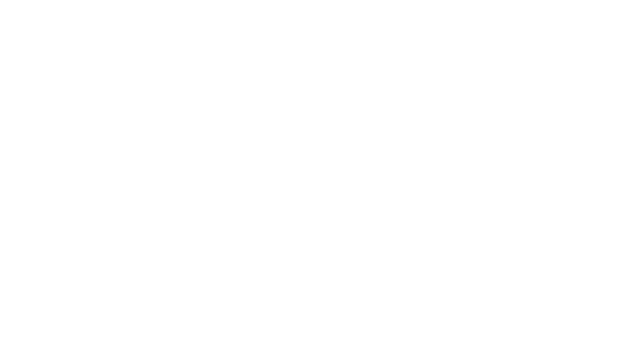

### Sampled frame at 20s

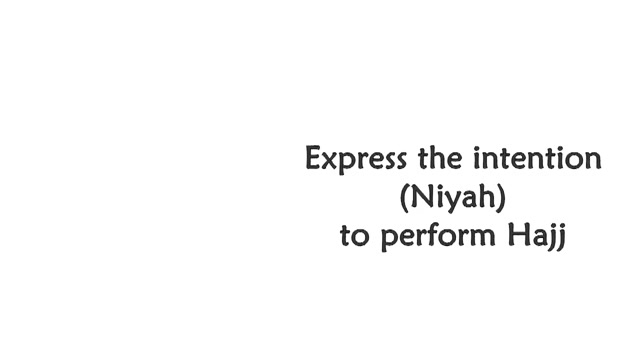

### Sampled frame at 40s

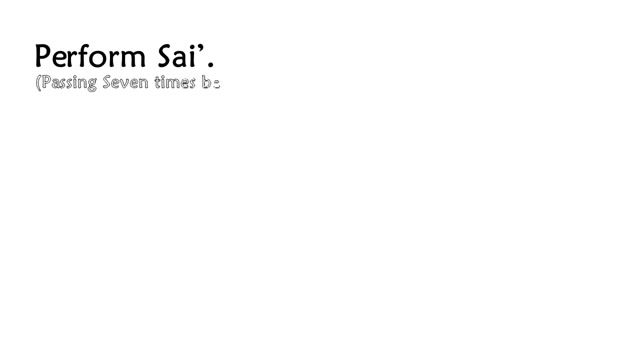

### Sampled frame at 60s

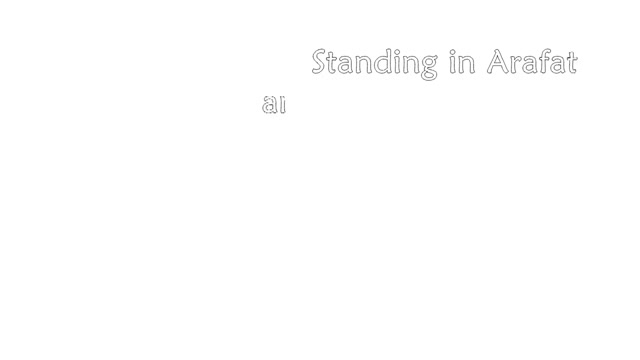

### Sampled frame at 80s

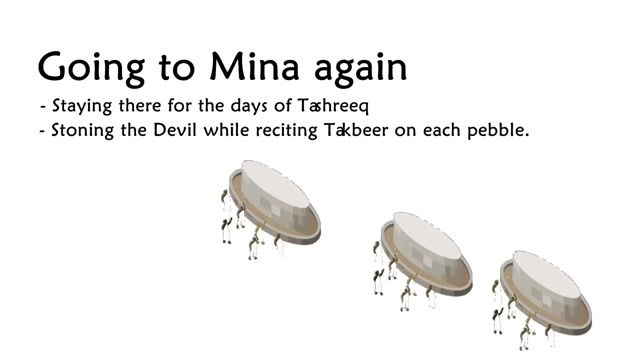

### Sampled frame at 100s

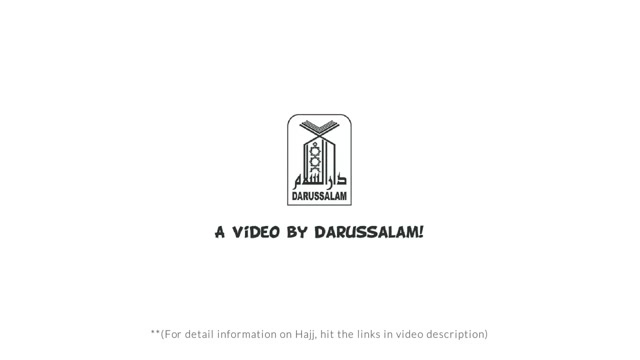

In [21]:
from IPython.display import display, Image as DisplayImage, Markdown

for path, timestamp in video_frames:
    display(Markdown(f'### Sampled frame at {timestamp:.0f}s'))
    display(DisplayImage(filename=str(path), width=720))


In [18]:
video_results = []
for path, timestamp in video_frames:
    item = vision.parse_image(path)[0]
    description = item.get('description', item.get('text', ''))
    entities = display_entities(item.get('entities'))
    row = {
        'frame': str(path),
        'timestamp_seconds': timestamp,
        'description': description,
        'entities': entities,
    }
    video_results.append(row)
    display(Markdown(f'### Description at {timestamp:.0f}s'))
    display(Markdown(description))
    display(Markdown('**Entities**'))
    display(DisplayJSON(entities))

video_results


### Description at 0s

المشهد: صورة سوداء بالكاملة | العناصر والعدد المرئي: لا يوجد | النص المرئي: لا يوجد نص مقروء | الأشخاص/المعالم والأسماء: لا يوجد | الموضع/الألوان والتفاصيل المعمارية: خلفية سوداء موحدة.

**Entities**

<IPython.core.display.JSON object>

### Description at 20s

...

### Description at 100s

المشهد: شاشة بيضاء تحتوي على شعار مؤسسة دار السلام، شعاراً أبيض وأسوداً، باللونين الأبيض والأسود. | العناصر والعدد المرئي: شعار واحد، نص واحد، نص فرعي. | النص المرئي: DARUSSALAM، A VIDEO BY DARUSSALAM!، **(For detail information on Hajj, hit the links in video description)**. | الأشخاص/المعالم والأسماء: دار السلام (Darussalam). | الموضع/الألوان والتفاصيل المعمارية: الشعار في المنتصف، النص في الأسفل، الخلفية بيضاء.

**Entities**

<IPython.core.display.JSON object>

[{'frame': '/Users/ushnah.abbasi/RAG-Anything/arabic_poc/notebook_frames/hajj_guide-20260923-030205/000001.jpg',
  'timestamp_seconds': 0,
  'description': 'المشهد: صورة سوداء بالكاملة | العناصر والعدد المرئي: لا يوجد | النص المرئي: لا يوجد نص مقروء | الأشخاص/المعالم والأسماء: لا يوجد | الموضع/الألوان والتفاصيل المعمارية: خلفية سوداء موحدة.',
  'entities': {'people': [],
   'landmarks': [],
   'places': [],
   'organizations': [],
   'events': []}},
 {'frame': '/Users/ushnah.abbasi/RAG-Anything/arabic_poc/notebook_frames/hajj_guide-20260923-030205/000002.jpg',
  'timestamp_seconds': 20,
  'description': 'المشهد: شاشة بيضاء فارغة مع نص باللغة الإنجليزية. | العناصر والعدد المرئي: نص مكتوب. | النص المرئي: Express the intention (Niyah) to perform Hajj. | الأشخاص/المعالم والأسماء: لا يوجد. | الموضع/الألوان والتفاصيل المعمارية: النص باللون الرمادي على خلفية بيضاء.',
  'entities': {'people': [],
   'landmarks': [],
   'places': [],
   'organizations': [],
   'events': ['Hajj']}},
 {'frame': '

In [19]:
video_output_path = ROOT / 'arabic_poc' / 'validation' / f'{VIDEO_PATH.stem}-visual-lab.json'
video_output_path.write_text(json.dumps({
    'input': str(VIDEO_PATH),
    'frame_seconds': VIDEO_FRAME_SECONDS,
    'description_provider': provider,
    'results': video_results,
}, ensure_ascii=False, indent=2), encoding='utf-8')
print(f'Saved: {video_output_path}')


Saved: /Users/ushnah.abbasi/RAG-Anything/arabic_poc/validation/hajj_guide-visual-lab.json
